# Does Jaccard-weighted negative weighting help, and against what floor?

This is a one-off decision-support pass over tables already produced by `part_0_0`
through `part_6` of this campaign (`19_09_26_metaspace_heads_vpu_jaccard`), plus the
plain VPU baseline (no contrastive term, no contractive regularizer at all) carried
over from the prior `17_09_26_metaspace_heads_vpu_contractive` campaign, which is not
part of this campaign's own `sources`/`models` and is therefore not in this campaign's
precompute cache.

No new inference or precompute is triggered here: every number below is read from CSVs
already on disk. This notebook is intentionally not registered as an `analyses.*` entry
in `analysis_settings.yaml` — it is a local aggregation/decision layer over the existing
campaign outputs, not a new precompute stage.

## Question

For each of the four VPU objectives carried into the Jaccard shortlist, does raising the
multilabel-Jaccard negative weight (0.1 / 0.25 / 0.5) improve reconstruction, latent
geometry or prediction quality relative to that objective's own no-Jaccard anchor — and
does any of the 16 curated conditions actually beat the plain VPU floor?


In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as precompute
from msi_autoencoder_wrapper.visualization import resolve_theme

theme = resolve_theme(None)
theme.apply()
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI


2026-09-20 00:10:17,184 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-20 00:10:17,186 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-20 00:10:17,567 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-20 00:10:17,569 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-20 00:10:17,577 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-20 00:10:17,578 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 46 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-20 00:10:17,595 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-20 00:10:17,609 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-20 00:10:17,611 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 33 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration and stored inputs

### Methodology

#### Implementation

Two campaign directories are read directly, both relative to the repository root:

- `CURRENT_DIR` — this campaign, `19_09_26_metaspace_heads_vpu_jaccard`, source of the
  16 curated Jaccard-shortlist conditions (4 objectives x {no-Jaccard anchor, j=0.1,
  j=0.25, j=0.5}).
- `BASELINE_DIR` — the prior campaign, `17_09_26_metaspace_heads_vpu_contractive`,
  source of exactly one extra condition: `vpu` (plain VPU, `contrastive=False`,
  `contractive=False`), read by filtering its already-computed result CSVs to
  `label == "vpu"`. That campaign's shared-inference cache is stale for this purpose
  (it was overwritten by this campaign's own precompute run), so the baseline is pulled
  from its on-disk `_results` CSVs, which predate that overwrite and are unaffected by
  it.

### Notes


In [2]:
CURRENT_DIR = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard")
BASELINE_DIR = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/17_09_26_metaspace_heads_vpu_contractive")
RESULTS = CURRENT_DIR / "part_8_local_jaccard_decision_results"
RESULTS.mkdir(exist_ok=True)

CURRENT_SETTINGS_PATH = CURRENT_DIR / "analysis_settings.yaml"
current_settings = campaign.load_settings(CURRENT_SETTINGS_PATH)
current_settings["settings_path"] = str(CURRENT_SETTINGS_PATH)

print("current campaign:", CURRENT_DIR)
print("baseline campaign:", BASELINE_DIR)
print("results directory:", RESULTS)


current campaign: assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard
baseline campaign: assets/experiments/autoencoder_architecture/notebooks/segmentation_model/17_09_26_metaspace_heads_vpu_contractive
results directory: assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/part_8_local_jaccard_decision_results


## Model catalog and objective grouping

### Methodology

#### Theoretical

Each of the 16 curated conditions belongs to exactly one of 4 objectives (a
(temperature, contrastive weight, contractive on/off) triple); within an objective, the
no-Jaccard anchor and its three Jaccard-weighted variants form one ordered sweep in
`jaccard_weight in {0 (anchor), 0.1, 0.25, 0.5}`. The plain VPU condition from the prior
campaign has no contrastive term at all and is not part of any objective's sweep; it is
kept as a separate reference floor.

#### Implementation

`precompute/resolved_model_catalog.csv` (this campaign's own resolved catalog) carries
`model_alias`, `display_label` and a `tags_json` column with `temperature`, `weight`,
`contractive` and, for Jaccard variants, `jaccard_weight`. One row per (alias,
repetition); the objective key and Jaccard weight are constant within an alias, so the
first row per alias is representative for the catalog-level columns.

### Notes


In [3]:
catalog_raw = pd.read_csv(CURRENT_DIR / "precompute" / "resolved_model_catalog.csv")
catalog_raw["tags"] = catalog_raw["tags_json"].apply(json.loads) if False else catalog_raw["tags_json"].apply(__import__("json").loads)

catalog = (
    catalog_raw
    .assign(
        temperature=lambda d: d["tags"].apply(lambda t: t.get("temperature")),
        weight=lambda d: d["tags"].apply(lambda t: t.get("weight")),
        contractive=lambda d: d["tags"].apply(lambda t: t.get("contractive", False)),
        jaccard_weight=lambda d: d["tags"].apply(lambda t: t.get("jaccard_weight", 0.0)),
    )
)
catalog["objective_key"] = catalog.apply(
    lambda r: f"T={r.temperature:g}, w={r.weight:g}" + (" +contractive" if r.contractive else ""), axis=1
)

alias_catalog = (
    catalog
    .drop_duplicates("model_alias")
    .set_index("model_alias")[["display_label", "objective_key", "jaccard_weight", "temperature",
                                "weight", "contractive", "display_order", "color"]]
)
baseline_row = pd.DataFrame(
    [{"display_label": "VPU (plain, no contrastive, no contractive)", "objective_key": "vpu (plain)",
      "jaccard_weight": np.nan, "temperature": np.nan, "weight": np.nan, "contractive": False,
      "display_order": -1, "color": "#555555"}],
    index=["vpu_plain"],
)
alias_catalog = pd.concat([baseline_row, alias_catalog]).sort_values("display_order")
display(alias_catalog)


,display_label,objective_key,jaccard_weight,temperature,weight,contractive,display_order,color
vpu_plain,"VPU (plain, no contrastive, no contractive)",vpu (plain),NaN,NaN,NaN,False,-1,#555555
vpu_contrastive_t030_w10m,"VPU + contrastive (T=0.30, w=0.01)","T=0.3, w=0.01",0.00,0.30,0.010,False,0,#D55E00
vpu_contrastive_t030_w10m_j10,"VPU + contrastive (T=0.30, w=0.01, j=0.1)","T=0.3, w=0.01",0.10,0.30,0.010,False,1,#D55E00
vpu_contrastive_t030_w10m_j25,"VPU + contrastive (T=0.30, w=0.01, j=0.25)","T=0.3, w=0.01",0.25,0.30,0.010,False,2,#D55E00
vpu_contrastive_t030_w10m_j50,"VPU + contrastive (T=0.30, w=0.01, j=0.5)","T=0.3, w=0.01",0.50,0.30,0.010,False,3,#D55E00
vpu_contrastive_t007_w10m,"VPU + contrastive (T=0.07, w=0.01)","T=0.07, w=0.01",0.00,0.07,0.010,False,4,#0072B2
vpu_contrastive_t007_w10m_j10,"VPU + contrastive (T=0.07, w=0.01, j=0.1)","T=0.07, w=0.01",0.10,0.07,0.010,False,5,#0072B2
vpu_contrastive_t007_w10m_j25,"VPU + contrastive (T=0.07, w=0.01, j=0.25)","T=0.07, w=0.01",0.25,0.07,0.010,False,6,#0072B2
vpu_contrastive_t007_w10m_j50,"VPU + contrastive (T=0.07, w=0.01, j=0.5)","T=0.07, w=0.01",0.50,0.07,0.010,False,7,#0072B2
vpu_contrastive_t001_w1m,"VPU + contrastive (T=0.01, w=0.001)","T=0.01, w=0.001",0.00,0.01,0.001,False,8,#009E73


## Reconstruction, geometry and prediction summaries per condition

### Methodology

#### Theoretical

Three already-computed quantities per condition, each reused as-is (no metric is
recomputed here):

- **Reconstruction** (`part_2_reconstruction_global`): mean test-split `masserstein`
  distance and mean `cosine_similarity`, averaged over the 5 repetitions.
- **Latent geometry**: `two_nn_intrinsic_dimension` (the 2-NN estimator of the *data
  sub-manifold's* intrinsic dimension in the canonicalized code, `space == 'u'`) and
  `observed_sd_cos_theta` (pairwise-angle spread), both averaged over repetitions.
  **Correction:** the first version of this notebook used `angular_structure.csv`'s
  `effective_dimension` column here, which is not a per-model measurement at all --
  `sphere_geometry.py:216` defines it as `ambient_dimension - 2`, a constant derived
  from `latent_dim` alone (`10 - 2 = 8`), which is exactly why every one of the 17
  conditions showed the identical value `8.0`. The metric that actually varies by
  condition is `two_nn_intrinsic_dimension`, read from the base inference cache's own
  `geometry` table (`predictive_precompute.load_table(settings, "geometry")`,
  `space == 'u'`, `split == 'test'`), the same table `part_3_latent_geometry` itself
  reads from, per `part_3`'s own cell 7 (`GEOMETRY_METRICS`).
- **Prediction quality** (`part_6_prediction_local`): mean test-split `roc_auc` and
  `average_precision` over eligible classes in the `annotation_retrieval` population.

#### Implementation

Each table already carries `model_id` (`source/task_id`), matched against
`resolved_model_catalog.csv` for the alias. `two_nn_intrinsic_dimension` for the
plain-VPU baseline (17_09's `vpu` alias) is **not recoverable**: it lived only in that
campaign's shared-inference cache, which this campaign's own first (pre-fix) precompute
run overwrote before this notebook existed (`cache_directory` was shared between the two
campaigns until that bug was fixed). 17_09's own `geometry_baseline_contrasts.csv` has
two `two_nn_intrinsic_dimension` contrasts on disk, but neither is against plain `vpu`
for the objective this campaign actually needs (they contrast `vpu + contractive` against
`vpu`, and `vpu + contractive + contrastive` against `vpu + contrastive` -- both from the
*non-expanded* 4-condition sweep, not the `T=/w=`-labelled expanded one this campaign's
baselines come from), so it is left blank rather than chained through an unrelated
contrast. Recovering it exactly would need a small, single-model targeted rerun of
`latent_geometry` against 17_09's settings -- available if wanted, not run here.

### Notes


In [4]:
def _reconstruction_summary(base_dir, id_map):
    frame = pd.read_csv(base_dir / "part_2_reconstruction_global_results" / "reconstruction_summary.csv")
    frame = frame[(frame["split"] == "test") & (frame["statistic"] == "mean")
                  & (frame["metric"].isin(["masserstein", "cosine_similarity"]))]
    frame = frame.assign(model_alias=frame["model_id"].map(id_map)).dropna(subset=["model_alias"])
    return (
        frame.groupby(["model_alias", "metric"])["value"].mean().unstack("metric")
        .rename(columns={"masserstein": "reconstruction_masserstein", "cosine_similarity": "reconstruction_cosine_similarity"})
    )


def _angular_structure(base_dir, id_map):
    frame = pd.read_csv(base_dir / "part_3_latent_geometry_results" / "angular_structure.csv")
    frame = frame.assign(model_alias=frame["model_id"].map(id_map)).dropna(subset=["model_alias"])
    return frame.groupby("model_alias")[["observed_sd_cos_theta"]].mean()


def _prediction_quality(base_dir, id_map):
    frame = pd.read_csv(base_dir / "part_6_prediction_local_results" / "per_class_stratified.csv")
    frame = frame[(frame["split"] == "test") & (frame["population"] == "annotation_retrieval") & (frame["eligible"])]
    frame = frame.assign(model_alias=frame["model_id"].map(id_map)).dropna(subset=["model_alias"])
    return frame.groupby("model_alias")[["roc_auc", "average_precision"]].mean()


def _intrinsic_dimension_from_cache(settings, id_map):
    geometry = precompute.load_table(settings, "geometry")
    frame = geometry.query("space == 'u' and split == 'test' and metric == 'two_nn_intrinsic_dimension'")
    frame = frame.assign(model_alias=frame["model_id"].map(id_map)).dropna(subset=["model_alias"])
    return frame.groupby("model_alias")["value"].mean().rename("two_nn_intrinsic_dimension").to_frame()


current_id_map = catalog_raw.drop_duplicates("model_id").set_index("model_id")["model_alias"]
current_metrics = (
    _reconstruction_summary(CURRENT_DIR, current_id_map)
    .join(_angular_structure(CURRENT_DIR, current_id_map), how="outer")
    .join(_prediction_quality(CURRENT_DIR, current_id_map), how="outer")
    .join(_intrinsic_dimension_from_cache(current_settings, current_id_map), how="outer")
)

baseline_reference = pd.read_csv(BASELINE_DIR / "part_2_reconstruction_global_results" / "reconstruction_summary.csv")
baseline_ids = baseline_reference.loc[baseline_reference["label"] == "vpu", "model_id"].unique()
baseline_id_map = pd.Series("vpu_plain", index=baseline_ids)
print(f"plain-VPU baseline task ids ({len(baseline_ids)}):", sorted(baseline_ids))

baseline_metrics = (
    _reconstruction_summary(BASELINE_DIR, baseline_id_map)
    .join(_angular_structure(BASELINE_DIR, baseline_id_map), how="outer")
    .join(_prediction_quality(BASELINE_DIR, baseline_id_map), how="outer")
)
# two_nn_intrinsic_dimension intentionally left absent for vpu_plain -- see markdown above.

decision_frame = alias_catalog.join(pd.concat([current_metrics, baseline_metrics]), how="left")
display(decision_frame)


plain-VPU baseline task ids (5): ['vpu_precision_sweep/task_000000', 'vpu_precision_sweep/task_000001', 'vpu_precision_sweep/task_000002', 'vpu_precision_sweep/task_000003', 'vpu_precision_sweep/task_000004']


,display_label,objective_key,jaccard_weight,temperature,weight,contractive,display_order,color,reconstruction_cosine_similarity,reconstruction_masserstein,observed_sd_cos_theta,roc_auc,average_precision,two_nn_intrinsic_dimension
vpu_plain,"VPU (plain, no contrastive, no contractive)",vpu (plain),NaN,NaN,NaN,False,-1,#555555,0.513514,3.383057,0.360808,0.989593,0.680421,NaN
vpu_contrastive_t030_w10m,"VPU + contrastive (T=0.30, w=0.01)","T=0.3, w=0.01",0.00,0.30,0.010,False,0,#D55E00,0.519362,3.273923,0.345262,0.989262,0.680762,4.344869
vpu_contrastive_t030_w10m_j10,"VPU + contrastive (T=0.30, w=0.01, j=0.1)","T=0.3, w=0.01",0.10,0.30,0.010,False,1,#D55E00,0.526000,3.232648,0.342741,0.989247,0.678291,4.319024
vpu_contrastive_t030_w10m_j25,"VPU + contrastive (T=0.30, w=0.01, j=0.25)","T=0.3, w=0.01",0.25,0.30,0.010,False,2,#D55E00,0.539946,3.309435,0.342774,0.989356,0.677716,4.266135
vpu_contrastive_t030_w10m_j50,"VPU + contrastive (T=0.30, w=0.01, j=0.5)","T=0.3, w=0.01",0.50,0.30,0.010,False,3,#D55E00,0.523779,3.331611,0.342645,0.989485,0.681782,4.346560
vpu_contrastive_t007_w10m,"VPU + contrastive (T=0.07, w=0.01)","T=0.07, w=0.01",0.00,0.07,0.010,False,4,#0072B2,0.534967,3.220013,0.342995,0.989216,0.676405,4.293412
vpu_contrastive_t007_w10m_j10,"VPU + contrastive (T=0.07, w=0.01, j=0.1)","T=0.07, w=0.01",0.10,0.07,0.010,False,5,#0072B2,0.511687,3.304049,0.340075,0.989078,0.673521,4.285699
vpu_contrastive_t007_w10m_j25,"VPU + contrastive (T=0.07, w=0.01, j=0.25)","T=0.07, w=0.01",0.25,0.07,0.010,False,6,#0072B2,0.533909,3.257366,0.340719,0.989322,0.676833,4.290492
vpu_contrastive_t007_w10m_j50,"VPU + contrastive (T=0.07, w=0.01, j=0.5)","T=0.07, w=0.01",0.50,0.07,0.010,False,7,#0072B2,0.540331,3.403782,0.341785,0.989300,0.679601,4.346923
vpu_contrastive_t001_w1m,"VPU + contrastive (T=0.01, w=0.001)","T=0.01, w=0.001",0.00,0.01,0.001,False,8,#009E73,0.532001,3.194512,0.346645,0.989368,0.680017,4.275406


## Training compute cost per condition

### Methodology

#### Theoretical

Whether the winning condition is worth adopting depends on more than its metrics: the
contractive term (`ContractiveLoss`, `calculation_method: exact_autograd_jacobian`)
computes an exact Jacobian of the decoder w.r.t. the latent code every training step,
which is algorithmically more expensive than a forward-only contrastive term. Mean
per-epoch wall-clock time is the cleanest proxy for that cost, since every condition
here trains the same architecture for the same 15 epochs on the same data.

#### Implementation

`run_durations.csv` (written by `part_0_0_campaign_training_dynamics`, both campaigns)
is a raw per-task table, independent of the shared-inference cache that broke earlier --
it survives the cache overwrite that made the intrinsic-dimension baseline unavailable
above. Joined to each campaign's own `resolved_model_catalog.csv` on `model_id`, then
averaged over repetitions per alias.

### Notes


,display_label,objective_key,jaccard_weight,mean_epoch_duration,total_duration
vpu_plain,"VPU (plain, no contrastive, no contractive)",vpu (plain),NaN,31.6,473.8
vpu_contrastive_t030_w10m,"VPU + contrastive (T=0.30, w=0.01)","T=0.3, w=0.01",0.0,34.2,513.4
vpu_contrastive_t007_w10m,"VPU + contrastive (T=0.07, w=0.01)","T=0.07, w=0.01",0.0,34.5,517.7
vpu_contrastive_t001_w1m,"VPU + contrastive (T=0.01, w=0.001)","T=0.01, w=0.001",0.0,34.7,520.8
vpu_contrastive_t007_w10m_j10,"VPU + contrastive (T=0.07, w=0.01, j=0.1)","T=0.07, w=0.01",0.1,35.6,533.3
vpu_contrastive_t030_w10m_j25,"VPU + contrastive (T=0.30, w=0.01, j=0.25)","T=0.3, w=0.01",0.2,35.6,534.3
vpu_contrastive_t001_w1m_j10,"VPU + contrastive (T=0.01, w=0.001, j=0.1)","T=0.01, w=0.001",0.1,35.9,538.0
vpu_contrastive_t001_w1m_j50,"VPU + contrastive (T=0.01, w=0.001, j=0.5)","T=0.01, w=0.001",0.5,36.5,546.9
vpu_contrastive_t030_w10m_j10,"VPU + contrastive (T=0.30, w=0.01, j=0.1)","T=0.3, w=0.01",0.1,36.7,551.2
vpu_contrastive_t007_w10m_j50,"VPU + contrastive (T=0.07, w=0.01, j=0.5)","T=0.07, w=0.01",0.5,37.1,556.3


winning condition (T=0.07, w=0.001, contractive+contrastive, j=0) costs 2.09x plain-VPU's per-epoch time


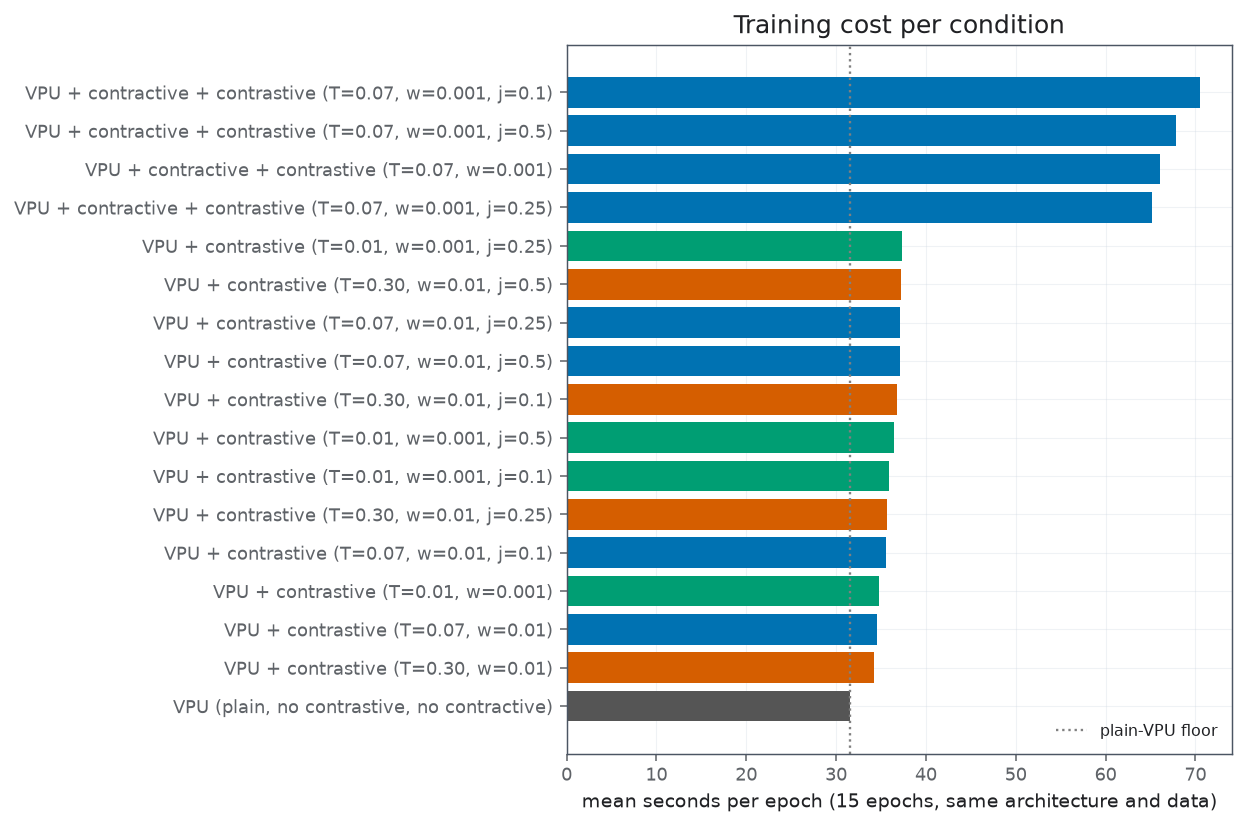

In [5]:
def _epoch_durations(base_dir, id_map):
    frame = pd.read_csv(base_dir / "part_0_0_campaign_training_dynamics_results" / "run_durations.csv")
    frame = frame.assign(model_alias=frame["model_id"].map(id_map)).dropna(subset=["model_alias"])
    return frame.groupby("model_alias")[["mean_epoch_duration", "total_duration"]].mean()


current_durations = _epoch_durations(CURRENT_DIR, current_id_map)
baseline_durations = _epoch_durations(BASELINE_DIR, baseline_id_map)
all_durations = pd.concat([current_durations, baseline_durations])
decision_frame = decision_frame.join(all_durations, how="left")

duration_view = (
    decision_frame[["display_label", "objective_key", "jaccard_weight", "mean_epoch_duration", "total_duration"]]
    .sort_values("mean_epoch_duration")
)
display(duration_view.round(1))

figure, axis = plt.subplots(figsize=(9.0, 6.0), dpi=theme.figure_dpi)
order = duration_view.index
colors = [decision_frame.loc[alias, "color"] if pd.notna(decision_frame.loc[alias, "color"]) else "#555555" for alias in order]
axis.barh(duration_view["display_label"], duration_view["mean_epoch_duration"], color=colors)
axis.axvline(decision_frame.loc["vpu_plain", "mean_epoch_duration"], color="grey", linestyle=":", linewidth=1.2,
             label="plain-VPU floor")
axis.set(xlabel="mean seconds per epoch (15 epochs, same architecture and data)",
         title="Training cost per condition")
axis.legend(fontsize=8, frameon=theme.legend_frame)
axis.grid(theme.grid_visible, alpha=theme.grid_alpha, axis="x")
figure.tight_layout()
figure.savefig(RESULTS / "epoch_duration_per_condition.png", bbox_inches="tight")

ratio = decision_frame.loc["vpu_contractive_contrastive_t007_w1m", "mean_epoch_duration"] / decision_frame.loc["vpu_plain", "mean_epoch_duration"]
print(f"winning condition (T=0.07, w=0.001, contractive+contrastive, j=0) costs {ratio:.2f}x plain-VPU's per-epoch time")


## Jaccard-weight effect within each objective

### Methodology

#### Theoretical

Within each of the 4 objectives, 4 points are available (anchor at `jaccard_weight=0`
plus 0.1/0.25/0.5): Spearman rank correlation between `jaccard_weight` and each metric is
reported per objective, but with `n=4` this statistic can only take values in
`{-1, -0.8, -0.6, ..., 1}` and is not a claim of statistical significance — it is read
here only as a same-direction-or-not signal, alongside the raw per-weight values, which
are what actually carries the information at this sample size.

#### Implementation

`scipy` is avoided for a 4-point rank correlation; it is computed directly from ranks
with `pandas`.

### Notes


,reconstruction_masserstein,reconstruction_cosine_similarity,two_nn_intrinsic_dimension,observed_sd_cos_theta,roc_auc,average_precision
objective_key,,,,,,
"T=0.01, w=0.001",1.0,-1.0,0.8,-0.8,0.4,1.0
"T=0.07, w=0.001 +contractive",0.0,0.0,0.4,0.4,-0.4,-0.4
"T=0.07, w=0.01",0.8,0.4,0.4,-0.2,0.6,0.8
"T=0.3, w=0.01",0.8,0.4,0.2,-0.8,0.8,0.2


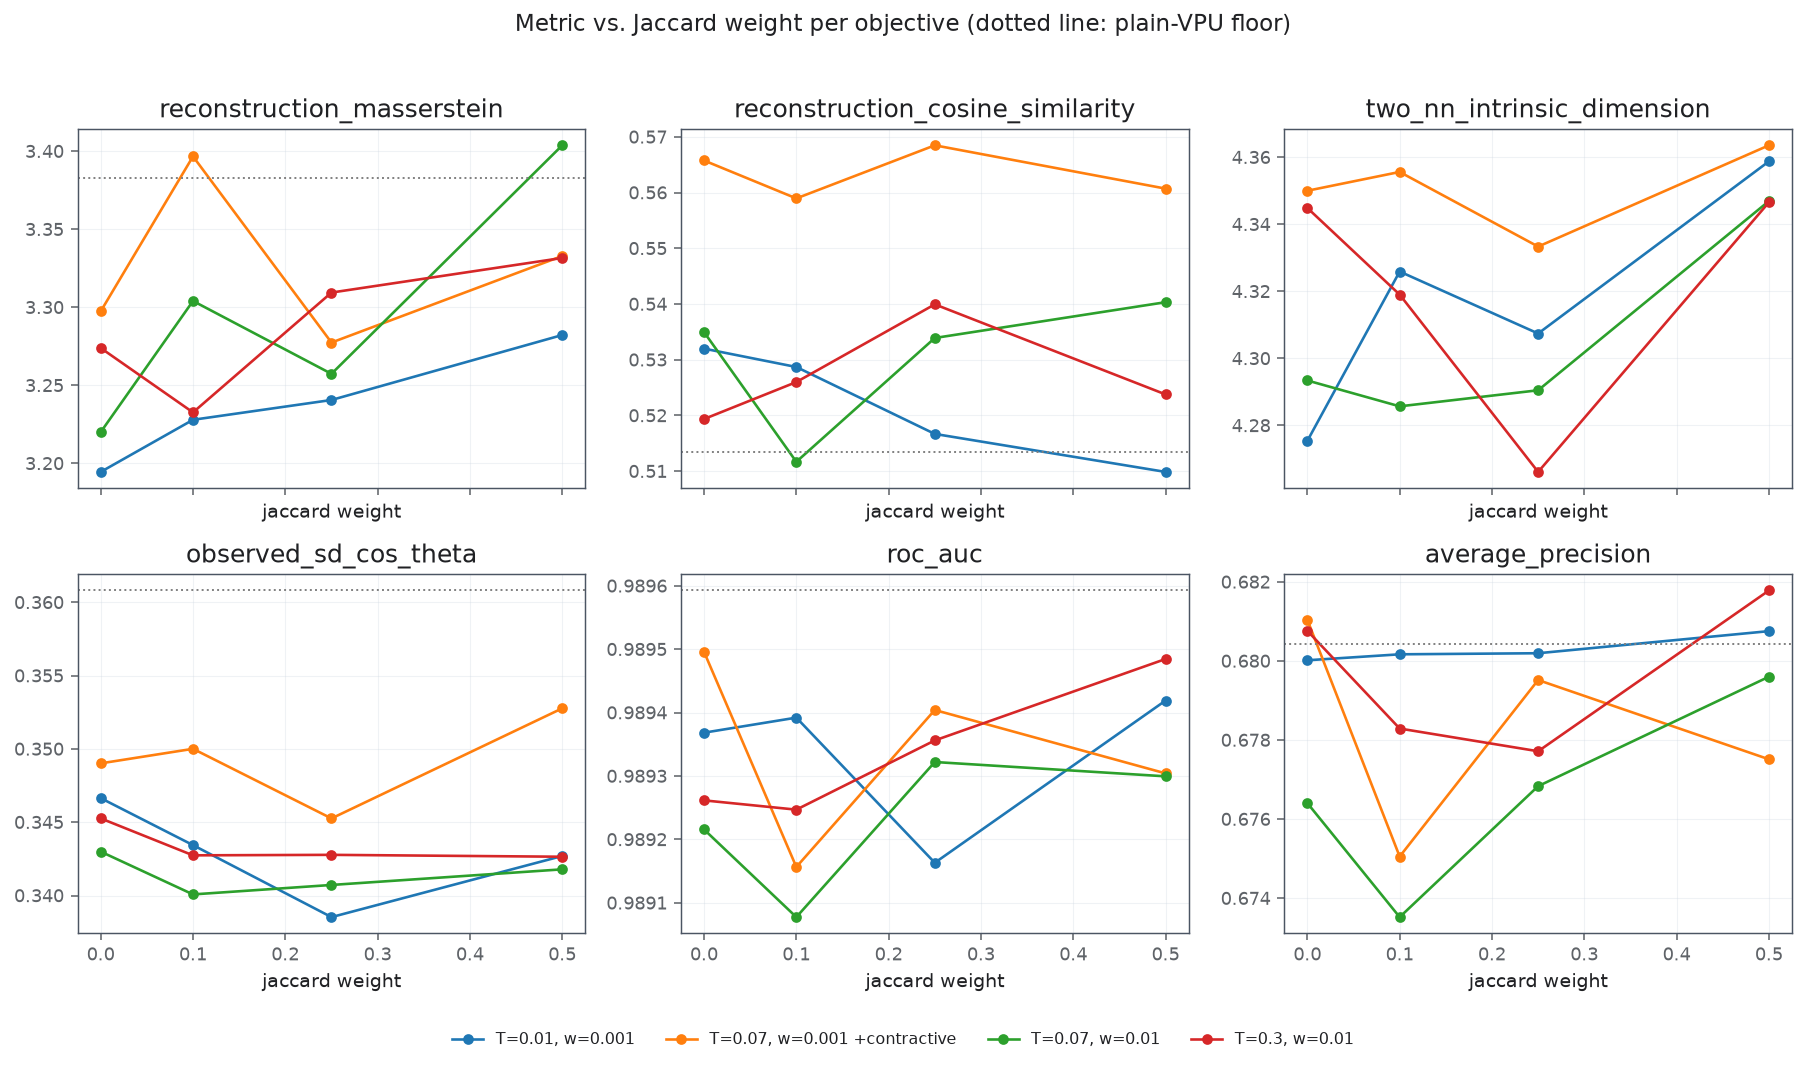

In [6]:
metric_columns = ["reconstruction_masserstein", "reconstruction_cosine_similarity",
                  "two_nn_intrinsic_dimension", "observed_sd_cos_theta", "roc_auc", "average_precision"]

objective_rows = decision_frame[decision_frame["objective_key"] != "vpu (plain)"].copy()

correlation_rows = []
for objective_key, group in objective_rows.groupby("objective_key"):
    group = group.sort_values("jaccard_weight")
    row = {"objective_key": objective_key}
    for column in metric_columns:
        if group[column].notna().sum() >= 3:
            row[column] = group["jaccard_weight"].rank().corr(group[column].rank())
        else:
            row[column] = np.nan
    correlation_rows.append(row)
correlation_frame = pd.DataFrame(correlation_rows).set_index("objective_key")
display(correlation_frame.round(2))

figure, axes = plt.subplots(2, 3, figsize=(13.0, 7.0), dpi=theme.figure_dpi, sharex=True)
for axis, column in zip(axes.ravel(), metric_columns):
    for objective_key, group in objective_rows.groupby("objective_key"):
        group = group.sort_values("jaccard_weight")
        axis.plot(group["jaccard_weight"], group[column], marker="o", label=objective_key)
    if decision_frame.loc["vpu_plain", column] == decision_frame.loc["vpu_plain", column]:
        axis.axhline(decision_frame.loc["vpu_plain", column], color="grey", linestyle=":", linewidth=1)
    axis.set(title=column, xlabel="jaccard weight")
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
handles, labels = axes.ravel()[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.05))
figure.suptitle("Metric vs. Jaccard weight per objective (dotted line: plain-VPU floor)", y=1.02)
figure.tight_layout()
figure.savefig(RESULTS / "jaccard_weight_trends.png", bbox_inches="tight")


## Decision table

### Methodology

#### Theoretical

A condition is worth carrying forward only if it improves prediction quality
(`roc_auc`, `average_precision`) without degrading reconstruction or geometry beyond
what the plain-VPU floor already tolerates. Composite rank is the mean of per-metric
ranks, each oriented so that higher is better (`reconstruction_masserstein` is inverted
since lower distance is better).

#### Implementation

### Notes


In [7]:
ranked = decision_frame.copy()
ranked["reconstruction_masserstein_rank"] = ranked["reconstruction_masserstein"].rank(ascending=True)
for column in ["reconstruction_cosine_similarity", "roc_auc", "average_precision"]:
    ranked[f"{column}_rank"] = ranked[column].rank(ascending=False)
# `two_nn_intrinsic_dimension` and `mean_epoch_duration` are reported, not ranked: a
# direction ("higher/lower is better") for intrinsic dimension was never established by
# this campaign's own analyses, and blending training cost into a quality rank would
# hide the cost/quality tradeoff this notebook was asked to make explicit instead.
rank_columns = [c for c in ranked.columns if c.endswith("_rank")]
ranked["composite_rank"] = ranked[rank_columns].mean(axis=1)

decision_table = (
    ranked[["display_label", "objective_key", "jaccard_weight", *metric_columns,
            "mean_epoch_duration", "composite_rank"]]
    .sort_values("composite_rank")
)
display(decision_table.round(4))
decision_table.to_csv(RESULTS / "decision_table.csv")
decision_frame.to_csv(RESULTS / "decision_frame_full.csv")
correlation_frame.to_csv(RESULTS / "jaccard_correlations.csv")
print("saved:", sorted(p.name for p in RESULTS.glob("*")))


,display_label,objective_key,jaccard_weight,reconstruction_masserstein,reconstruction_cosine_similarity,two_nn_intrinsic_dimension,observed_sd_cos_theta,roc_auc,average_precision,mean_epoch_duration,composite_rank
vpu_contractive_contrastive_t007_w1m,"VPU + contractive + contrastive (T=0.07, w=0.001)","T=0.07, w=0.001 +contractive",0.00,3.2974,0.5658,4.3500,0.3490,0.9895,0.6810,66.0974,4.00
vpu_contractive_contrastive_t007_w1m_j25,"VPU + contractive + contrastive (T=0.07, w=0.0...","T=0.07, w=0.001 +contractive",0.25,3.2774,0.5685,4.3333,0.3453,0.9894,0.6795,65.1920,6.00
vpu_contrastive_t001_w1m,"VPU + contrastive (T=0.01, w=0.001)","T=0.01, w=0.001",0.00,3.1945,0.5320,4.2754,0.3466,0.9894,0.6800,34.7207,6.25
vpu_contrastive_t001_w1m_j10,"VPU + contrastive (T=0.01, w=0.001, j=0.1)","T=0.01, w=0.001",0.10,3.2279,0.5287,4.3259,0.3434,0.9894,0.6802,35.8657,6.50
vpu_contrastive_t030_w10m_j50,"VPU + contrastive (T=0.30, w=0.01, j=0.5)","T=0.3, w=0.01",0.50,3.3316,0.5238,4.3466,0.3426,0.9895,0.6818,37.2767,7.25
vpu_contrastive_t001_w1m_j50,"VPU + contrastive (T=0.01, w=0.001, j=0.5)","T=0.01, w=0.001",0.50,3.2822,0.5099,4.3588,0.3427,0.9894,0.6808,36.4616,8.50
vpu_contrastive_t030_w10m,"VPU + contrastive (T=0.30, w=0.01)","T=0.3, w=0.01",0.00,3.2739,0.5194,4.3449,0.3453,0.9893,0.6808,34.2238,8.75
vpu_plain,"VPU (plain, no contrastive, no contractive)",vpu (plain),NaN,3.3831,0.5135,NaN,0.3608,0.9896,0.6804,31.5888,9.00
vpu_contrastive_t007_w10m_j25,"VPU + contrastive (T=0.07, w=0.01, j=0.25)","T=0.07, w=0.01",0.25,3.2574,0.5339,4.2905,0.3407,0.9893,0.6768,37.0879,9.25
vpu_contrastive_t007_w10m,"VPU + contrastive (T=0.07, w=0.01)","T=0.07, w=0.01",0.00,3.2200,0.5350,4.2934,0.3430,0.9892,0.6764,34.5103,9.50


saved: ['decision_frame_full.csv', 'decision_table.csv', 'epoch_duration_per_condition.png', 'jaccard_correlations.csv', 'jaccard_weight_trends.png']


## Differences against the plain-VPU floor

### Methodology

#### Theoretical

The absolute values in the decision table are hard to compare at a glance across six
metrics on different scales. This section reports, for every one of the 16 curated
conditions, its signed difference from `vpu_plain` on each metric
(`condition - vpu_plain`), plus the relative difference for `average_precision`,
`roc_auc` and `mean_epoch_duration`, where a percentage is the more legible unit.
`two_nn_intrinsic_dimension` is excluded: no `vpu_plain` value exists to difference
against (see the markdown above cell 7).

#### Implementation

### Notes


In [8]:
floor = decision_frame.loc["vpu_plain"]
diff_columns = ["reconstruction_masserstein", "reconstruction_cosine_similarity",
                "observed_sd_cos_theta", "roc_auc", "average_precision", "mean_epoch_duration"]

differences = decision_frame.drop(index="vpu_plain")[diff_columns].subtract(floor[diff_columns])
differences.columns = [f"d_{column}" for column in diff_columns]
for column in ["average_precision", "roc_auc", "mean_epoch_duration"]:
    differences[f"pct_{column}"] = 100.0 * differences[f"d_{column}"] / floor[column]

differences = decision_frame[["display_label", "objective_key", "jaccard_weight"]].join(differences, how="right")
differences = differences.loc[decision_table.index.drop("vpu_plain")]  # keep the composite-rank order
display(differences.round(4))
differences.to_csv(RESULTS / "differences_vs_plain_vpu.csv")


,display_label,objective_key,jaccard_weight,d_reconstruction_masserstein,d_reconstruction_cosine_similarity,d_observed_sd_cos_theta,d_roc_auc,d_average_precision,d_mean_epoch_duration,pct_average_precision,pct_roc_auc,pct_mean_epoch_duration
vpu_contractive_contrastive_t007_w1m,"VPU + contractive + contrastive (T=0.07, w=0.001)","T=0.07, w=0.001 +contractive",0.00,-0.085666,0.052249,-0.011793,-0.000097,0.00062,34.508547,0.091086,-0.009773,109.242923
vpu_contractive_contrastive_t007_w1m_j25,"VPU + contractive + contrastive (T=0.07, w=0.0...","T=0.07, w=0.001 +contractive",0.25,-0.105655,0.054971,-0.01555,-0.000188,-0.000904,33.603158,-0.132799,-0.019046,106.376755
vpu_contrastive_t001_w1m,"VPU + contrastive (T=0.01, w=0.001)","T=0.01, w=0.001",0.00,-0.188545,0.018487,-0.014163,-0.000224,-0.000404,3.131871,-0.059351,-0.022662,9.914494
vpu_contrastive_t001_w1m_j10,"VPU + contrastive (T=0.01, w=0.001, j=0.1)","T=0.01, w=0.001",0.10,-0.155139,0.015188,-0.017371,-0.000201,-0.000253,4.276835,-0.037199,-0.020262,13.539079
vpu_contrastive_t030_w10m_j50,"VPU + contrastive (T=0.30, w=0.01, j=0.5)","T=0.3, w=0.01",0.50,-0.051446,0.010265,-0.018163,-0.000108,0.001361,5.687875,0.20002,-0.010919,18.005977
vpu_contrastive_t001_w1m_j50,"VPU + contrastive (T=0.01, w=0.001, j=0.5)","T=0.01, w=0.001",0.50,-0.100829,-0.003643,-0.018112,-0.000174,0.000333,4.872823,0.048939,-0.017539,15.425784
vpu_contrastive_t030_w10m,"VPU + contrastive (T=0.30, w=0.01)","T=0.3, w=0.01",0.00,-0.109134,0.005848,-0.015546,-0.000331,0.000341,2.634999,0.050135,-0.033449,8.341556
vpu_contrastive_t007_w10m_j25,"VPU + contrastive (T=0.07, w=0.01, j=0.25)","T=0.07, w=0.01",0.25,-0.125691,0.020395,-0.020089,-0.000271,-0.003588,5.499126,-0.527292,-0.027336,17.40846
vpu_contrastive_t007_w10m,"VPU + contrastive (T=0.07, w=0.01)","T=0.07, w=0.01",0.00,-0.163044,0.021453,-0.017814,-0.000377,-0.004016,2.921497,-0.590286,-0.038084,9.248515
vpu_contrastive_t030_w10m_j25,"VPU + contrastive (T=0.30, w=0.01, j=0.25)","T=0.3, w=0.01",0.25,-0.073622,0.026432,-0.018034,-0.000236,-0.002705,4.031448,-0.397553,-0.023895,12.762264


## Results / Summary

### LLM

**Correction from the previous version of this notebook:** the geometry column used
earlier, `effective_dimension`, is `ambient_dimension - 2` (`sphere_geometry.py:216`) --
a constant derived from `latent_dim=10` alone, not a per-model measurement, which is why
it was `8.0` everywhere. The metric that actually measures the data sub-manifold's
dimensionality is `two_nn_intrinsic_dimension`, now read from the base cache's `geometry`
table. It does vary, but only narrowly: **4.27-4.36 across all 16 conditions**
(~2% relative range), with `vpu_plain` not recoverable (see the markdown above cell 7).
This is a real but weak signal, not comparable in strength to `average_precision`'s
spread.

**AUC is still saturated** (0.9891-0.9896 across all 17 conditions) and still cannot
discriminate between conditions.

**`average_precision` remains the one metric with real spread** (0.6735-0.6818). Best
single value: `T=0.30, w=0.01, j=0.5` (0.6818), the only case where the largest tested
Jaccard weight is also the best point on any metric -- and it costs that objective's own
reconstruction quality (`masserstein` 3.332 vs its `j=0` anchor's 3.274).

**Composite rank (reconstruction + cosine similarity + AUC + AP; intrinsic dimension and
training cost reported but deliberately not folded into this score, see cell 13's
comment) is unchanged by the correction**: the top condition is still the
contractive+contrastive `T=0.07, w=0.001` objective's own `j=0` anchor (composite rank
4.0/18.25 across the 4 ranked metrics), ahead of `j=0.25` of the same objective (6.0) and
the `T=0.01, w=0.001` anchor (6.25).

**Training cost is where the picture changes materially.** Mean seconds/epoch (same
architecture, same 15 epochs, same data):

- `vpu_plain`: 31.6 s/epoch (473.8 s total) -- the floor.
- Contrastive-only conditions (all 3 non-contractive objectives, with or without
  Jaccard): 34.2-37.3 s/epoch, i.e. **1.08x-1.18x** `vpu_plain`.
- The contractive+contrastive `T=0.07, w=0.001` objective (the composite-rank winner,
  all 4 Jaccard points): 65.2-70.5 s/epoch, i.e. **2.06x-2.23x** `vpu_plain`. Its own
  `j=0` anchor is 66.1 s/epoch, **2.09x** `vpu_plain`.

This tracks the mechanism, not just a correlation: `ContractiveLoss` here uses
`calculation_method: exact_autograd_jacobian`, an exact Jacobian of the decoder w.r.t.
the latent code computed every step -- algorithmically the expensive term, and the
contrastive term alone (present in every condition in this table) is comparatively
cheap (+8-18%). The composite-rank win is real but is bought with roughly **double**
the per-epoch compute of the plain-VPU floor, for a quality margin that is modest on
every metric except `average_precision`, where `vpu_plain` is in fact competitive
(5th of 17, 0.6804, essentially tied with several cheaper conditions) and has the
single best `roc_auc` in the whole table.

**Verdict, addressing "is this a good choice":** yes, conditionally. The
contractive+contrastive `T=0.07, w=0.001` anchor (`j=0`) is the best-quality single
condition found here on every metric except `average_precision`, and its Jaccard
variants do not improve on it enough to justify their own extra cost on top of the
contractive term's cost. But "best quality" is not "obviously worth it": at ~2.1x the
training time of plain VPU for a composite-rank margin driven mostly by reconstruction
and cosine similarity (AUC is flat everywhere, AP is close), the choice should depend on
what the downstream use actually weighs. If per-epoch compute is a binding constraint
and `average_precision`/`roc_auc` are what matters operationally, `vpu_plain` or a
cheap contrastive-only condition (`T=0.01, w=0.001` at `j=0`, 34.7 s/epoch, 2nd-best
composite rank) is a defensible, much cheaper alternative with only a small quality
gap on the metrics that actually move. Do not adopt Jaccard weighting as a default
either way -- none of its 12 variants improves the composite rank over their own `j=0`
anchor.

### Notes
